# 01_dataset

- Defines DeclipDataset and imports from util.py
- Creates PyTorch DataLoader for train and val sets
- Verifies batch loading, shapes, and in-situ clipping

In [1]:
# Imports

import sys
import torch
from torch.utils.data import DataLoader

sys.path.insert(0, "..")
from config import *
from util import DeclipDataset

In [3]:
# Dataset and Dataloader instantiation

train_dataset = DeclipDataset(TRAIN_OUT / "train_blocks.pt", TRAIN_OUT / "train_manifest.json")
val_dataset = DeclipDataset(VAL_OUT / "val_blocks.pt", VAL_OUT / "val_manifest.json")

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples:   {len(val_dataset)}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")

Train samples: 225045
Val samples:   28131
Train batches: 7033
Val batches:   880


In [4]:
# Verifications

# Grab a single batch and verify shapes
clipped_batch, clean_batch = next(iter(train_loader))

print(f"Clipped batch shape: {clipped_batch.shape}")
print(f"Clean batch shape:   {clean_batch.shape}")
print(f"Clipped value range: [{clipped_batch.min():.3f}, {clipped_batch.max():.3f}]")
print(f"Clean value range:   [{clean_batch.min():.3f}, {clean_batch.max():.3f}]")

# Verify clipping: clipped max abs should be <= clean max abs
assert clipped_batch.abs().max() <= clean_batch.abs().max() + 1e-5, \
    "Clipped batch has values exceeding clean batch — clipping not applied correctly"

# Verify clipped range is strictly narrower for at least some samples
assert (clipped_batch.abs().max(dim=2).values < clean_batch.abs().max(dim=2).values).any(), \
    "No samples appear to be clipped"

print("All checks passed.")

Clipped batch shape: torch.Size([32, 1, 1024])
Clean batch shape:   torch.Size([32, 1, 1024])
Clipped value range: [-2.591, 2.591]
Clean value range:   [-6.425, 5.478]
All checks passed.


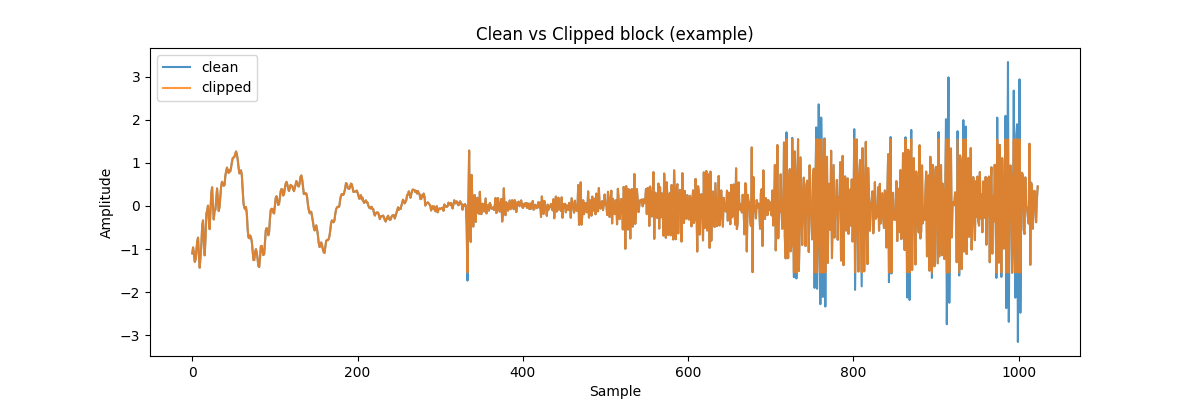

In [5]:
# Plot batch member

import matplotlib.pyplot as plt
import numpy as np
%matplotlib widget

idx = 0
clean_ex = clean_batch[idx, 0].numpy()
clipped_ex = clipped_batch[idx, 0].numpy()
t = np.arange(len(clean_ex))

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t, clean_ex, label="clean", alpha=0.8)
ax.plot(t, clipped_ex, label="clipped", alpha=0.8)
ax.set_xlabel("Sample")
ax.set_ylabel("Amplitude")
ax.set_title("Clean vs Clipped block (example)")
ax.legend()
plt.show()